In [14]:
import sys
!{sys.executable} -m pip install datasets
-m pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Users/carolinelingle/venvs/py312-pytorch/bin/python -m pip install --upgrade pip


In [3]:
from datasets import load_dataset

/Users/carolinelingle/venvs/py312-pytorch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from datasets import load_dataset
from collections import Counter
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# reproducibility
torch.manual_seed(42)
np.random.seed(42)

# load dataset
ds = load_dataset("Hemg/AI-Generated-vs-Real-Images-Datasets")
print("Dataset loaded.")
print(ds)

Dataset loaded.
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 152710
    })
})


Class counts: {'AiArtData': 81174, 'RealArt': 71536}
Class balance: 53.2% AI  |  46.8% Real


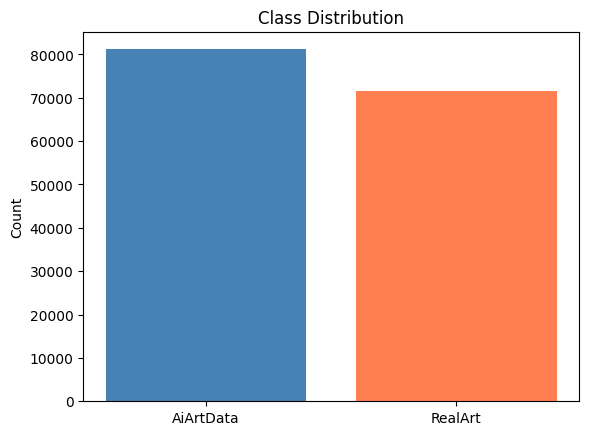

In [7]:
labels = ds['train']['label']
counts = Counter(labels)
class_names = ds['train'].features['label'].names  # ['AiArtData', 'RealArt']

print(f"Class counts: { {class_names[k]: v for k, v in counts.items()} }")
print(f"Class balance: {counts[0]/len(labels)*100:.1f}% AI  |  {counts[1]/len(labels)*100:.1f}% Real")

plt.bar(class_names, [counts[0], counts[1]], color=['steelblue', 'coral'])
plt.title("Class Distribution")
plt.ylabel("Count")
plt.show()

Width  — min: 32, max: 1110, median: 32
Height — min: 32, max: 600, median: 32
Per-channel means (R/G/B): 0.490 / 0.459 / 0.408


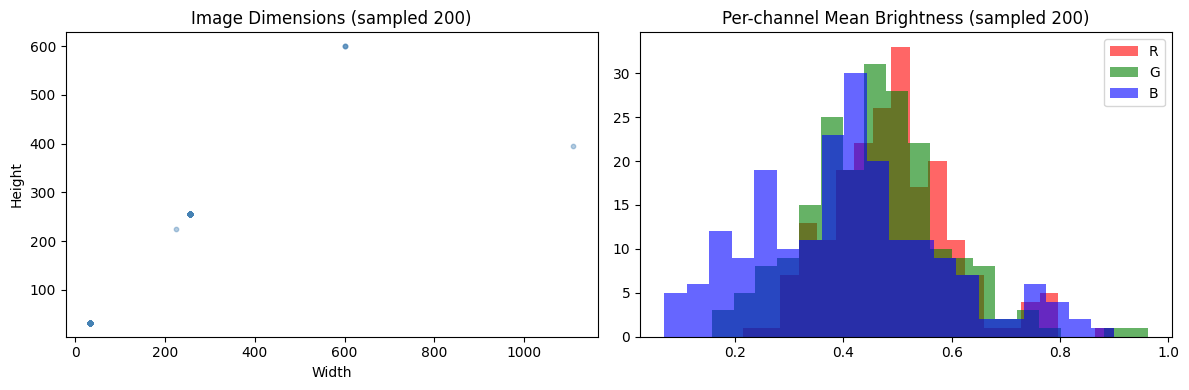

In [8]:
SAMPLE_N = 200
sample_indices = np.random.choice(len(ds['train']), SAMPLE_N, replace=False)

widths, heights, means_r, means_g, means_b = [], [], [], [], []

for i in sample_indices:
    img = ds['train'][int(i)]['image'].convert('RGB')
    w, h = img.size
    widths.append(w)
    heights.append(h)
    arr = np.array(img) / 255.0
    means_r.append(arr[:, :, 0].mean())
    means_g.append(arr[:, :, 1].mean())
    means_b.append(arr[:, :, 2].mean())

print(f"Width  — min: {min(widths)}, max: {max(widths)}, median: {int(np.median(widths))}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, median: {int(np.median(heights))}")
print(f"Per-channel means (R/G/B): {np.mean(means_r):.3f} / {np.mean(means_g):.3f} / {np.mean(means_b):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(widths, heights, alpha=0.4, s=10, color='steelblue')
axes[0].set_title("Image Dimensions (sampled 200)")
axes[0].set_xlabel("Width"); axes[0].set_ylabel("Height")

axes[1].hist(means_r, bins=20, alpha=0.6, label='R', color='red')
axes[1].hist(means_g, bins=20, alpha=0.6, label='G', color='green')
axes[1].hist(means_b, bins=20, alpha=0.6, label='B', color='blue')
axes[1].set_title("Per-channel Mean Brightness (sampled 200)")
axes[1].legend()
plt.tight_layout()
plt.show()

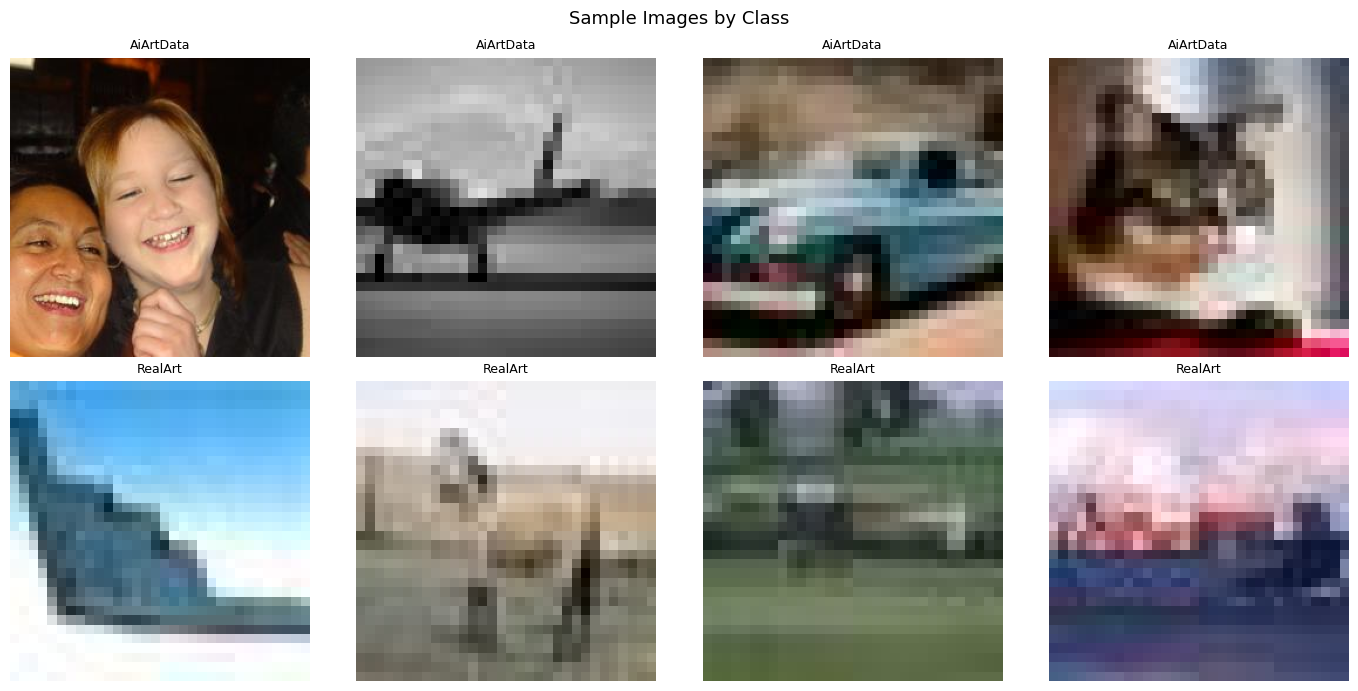

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for cls in [0, 1]:
    cls_indices = [i for i in range(len(ds['train'])) if ds['train'][i]['label'] == cls]
    chosen = np.random.choice(cls_indices, 4, replace=False)
    for col, idx in enumerate(chosen):
        img = ds['train'][int(idx)]['image'].convert('RGB')
        axes[cls][col].imshow(img)
        axes[cls][col].axis('off')
        axes[cls][col].set_title(class_names[cls], fontsize=9)

plt.suptitle("Sample Images by Class", fontsize=13)
plt.tight_layout()
plt.show()

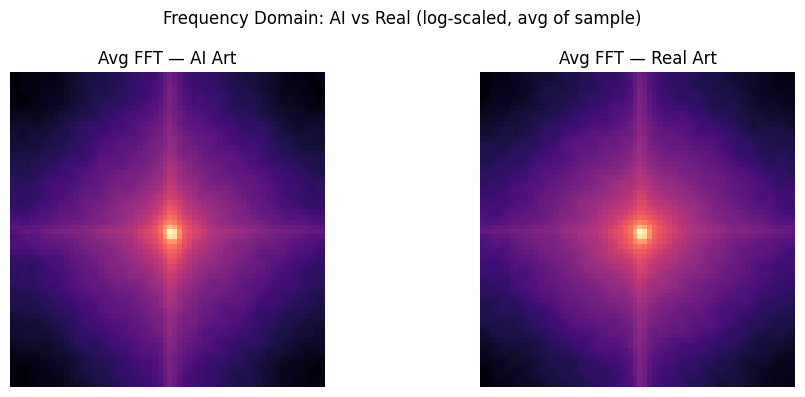

In [10]:
fft_ai, fft_real = [], []

for i in sample_indices:
    row = ds['train'][int(i)]
    img_gray = np.array(row['image'].convert('L'), dtype=np.float32)
    fft = np.fft.fftshift(np.abs(np.fft.fft2(img_gray)))
    log_fft = np.log1p(fft)
    # resize FFT to fixed 64x64 for averaging across different image sizes
    from PIL import Image as PILImage
    resized = np.array(PILImage.fromarray(log_fft).resize((64, 64)))
    if row['label'] == 0:
        fft_ai.append(resized)
    else:
        fft_real.append(resized)

avg_fft_ai   = np.mean(fft_ai, axis=0)
avg_fft_real = np.mean(fft_real, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(avg_fft_ai,   cmap='magma'); axes[0].set_title("Avg FFT — AI Art");   axes[0].axis('off')
axes[1].imshow(avg_fft_real, cmap='magma'); axes[1].set_title("Avg FFT — Real Art"); axes[1].axis('off')
plt.suptitle("Frequency Domain: AI vs Real (log-scaled, avg of sample)")
plt.tight_layout()
plt.show()

In [11]:
IMG_SIZE   = 64
BATCH_SIZE = 32

# normalization constants from sample above
NORM_MEAN = [np.mean(means_r), np.mean(means_g), np.mean(means_b)]
NORM_STD  = [np.std(means_r) + 1e-6, np.std(means_g) + 1e-6, np.std(means_b) + 1e-6]
print(f"Normalization — mean: {[round(m,3) for m in NORM_MEAN]}, std: {[round(s,3) for s in NORM_STD]}")

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD),
])

class AIvsRealDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.data      = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row   = self.data[idx]
        image = row['image'].convert('RGB')
        label = row['label']
        if self.transform:
            image = self.transform(image)
        return image, label

full_dataset = AIvsRealDataset(ds['train'], transform=transform)

# 70/15/15 split
n       = len(full_dataset)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val

train_ds, val_ds, test_ds = random_split(full_dataset, [n_train, n_val, n_test])
print(f"Split — Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

Normalization — mean: [np.float64(0.49), np.float64(0.459), np.float64(0.408)], std: [np.float64(0.111), np.float64(0.129), np.float64(0.172)]
Split — Train: 106897 | Val: 22906 | Test: 22907


In [12]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        preds      = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            outputs    = model(images)
            loss       = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds      = outputs.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += images.size(0)
    return total_loss / total, correct / total


def run_training(model, train_loader, val_loader, epochs=5, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history   = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)
        print(f"Epoch {epoch}/{epochs} — "
              f"Train Loss: {tr_loss:.4f}, Train Acc: {tr_acc:.4f} | "
              f"Val Loss: {va_loss:.4f}, Val Acc: {va_acc:.4f}")
    return history


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['val_loss'],   label='Val')
    axes[0].set_title(f"{title} — Loss"); axes[0].legend()
    axes[1].plot(history['train_acc'], label='Train')
    axes[1].plot(history['val_acc'],   label='Val')
    axes[1].set_title(f"{title} — Accuracy"); axes[1].legend()
    plt.tight_layout(); plt.show()

TinyCNN(
  (conv): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=2, bias=True)
  )
)
Total parameters: 16,610
Epoch 1/5 — Train Loss: 0.5474, Train Acc: 0.7308 | Val Loss: 0.5441, Val Acc: 0.7432
Epoch 2/5 — Train Loss: 0.5040, Train Acc: 0.7634 | Val Loss: 0.5056, Val Acc: 0.7704
Epoch 3/5 — Train Loss: 0.4903, Train Acc: 0.7715 | Val Loss: 0.5034, Val Acc: 0.7640
Epoch 4/5 — Train Loss: 0.4833, Train Acc: 0.7773 | Val Loss: 0.5046, Val Acc: 0.7677
Epoch 5/5 — Train Loss: 0.4744, Train Acc: 0.7834 | Val Loss: 0.4972, Val Acc: 0.7777


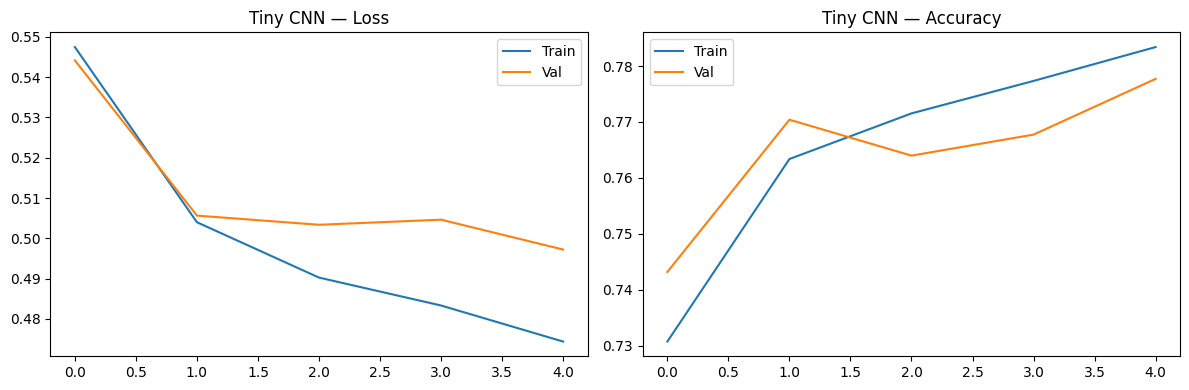


CNN Test Accuracy: 0.7779 | Test Loss: 0.5015


In [13]:
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 1 conv layer, 8 filters, 3x3 kernel
        self.conv = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 64x64 → 32x32
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8 * 32 * 32, 2)  # 2 output classes
        )

    def forward(self, x):
        return self.fc(self.conv(x))


cnn_model   = TinyCNN()
print(cnn_model)
total_params = sum(p.numel() for p in cnn_model.parameters())
print(f"Total parameters: {total_params:,}")

cnn_history = run_training(cnn_model, train_loader, val_loader, epochs=5)
plot_history(cnn_history, "Tiny CNN")

# test set eval
cnn_criterion       = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(cnn_model, test_loader, cnn_criterion)
print(f"\nCNN Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

TinyViT(
  (embedding): Linear(in_features=768, out_features=8, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=8, out_features=8, bias=True)
        )
        (linear1): Linear(in_features=8, out_features=16, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (linear2): Linear(in_features=16, out_features=8, bias=True)
        (norm1): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.0, inplace=False)
        (dropout2): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (classifier): Linear(in_features=8, out_features=2, bias=True)
)
Total parameters: 6,914
Epoch 1/5 — Train Loss: 0.6393, Train Acc: 0.6215 | Val Loss: 0.6186, Val Acc: 0.6441
Epoch 2/5 — Train Loss: 0.6092, Train Acc: 0.6527 | Val Los

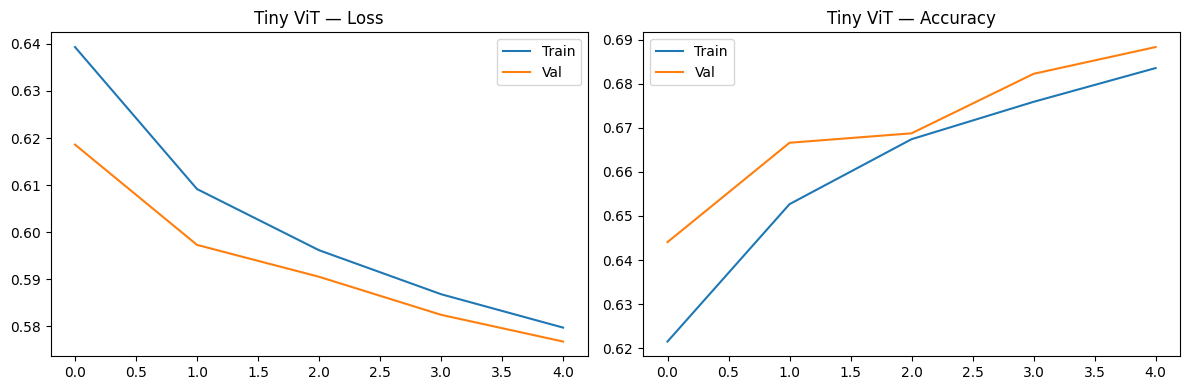


ViT Test Accuracy: 0.6856 | Test Loss: 0.5803


In [15]:
class TinyViT(nn.Module):
    """
    Minimal ViT — splits the image into patches, linearly embeds them,
    adds a [CLS] token, runs one transformer encoder layer, classifies.

    IMG_SIZE=64, patch_size=16 → 16 patches (4x4 grid)
    embed_dim=8, nhead=2 (must divide embed_dim evenly)
    """
    def __init__(self, img_size=64, patch_size=16, embed_dim=8, num_classes=2):
        super().__init__()
        assert img_size % patch_size == 0, "img_size must be divisible by patch_size"
        num_patches      = (img_size // patch_size) ** 2
        patch_dim        = 3 * patch_size * patch_size   # RGB pixels per patch

        self.patch_size  = patch_size
        self.embedding   = nn.Linear(patch_dim, embed_dim)
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed   = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        encoder_layer    = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=2, dim_feedforward=16,
            dropout=0.0, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.classifier  = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B, C, H, W = x.shape
        p = self.patch_size

        # Patchify: (B, num_patches, patch_dim)
        x = x.unfold(2, p, p).unfold(3, p, p)         # (B,C,H//p,W//p,p,p)
        x = x.contiguous().view(B, C, -1, p, p)        # (B,C,num_patches,p,p)
        x = x.permute(0, 2, 1, 3, 4)                   # (B,num_patches,C,p,p)
        x = x.flatten(2)                                # (B,num_patches,C*p*p)

        x   = self.embedding(x)                         # (B,num_patches,embed_dim)
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)                # prepend CLS token
        x   = x + self.pos_embed                        # add positional encoding

        x   = self.transformer(x)                       # (B, num_patches+1, embed_dim)
        cls_out = x[:, 0]                               # CLS token output only
        return self.classifier(cls_out)


vit_model   = TinyViT()
print(vit_model)
total_params = sum(p.numel() for p in vit_model.parameters())
print(f"Total parameters: {total_params:,}")

vit_history = run_training(vit_model, train_loader, val_loader, epochs=5)
plot_history(vit_history, "Tiny ViT")

# Test set evaluation
vit_criterion       = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(vit_model, test_loader, vit_criterion)
print(f"\nViT Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

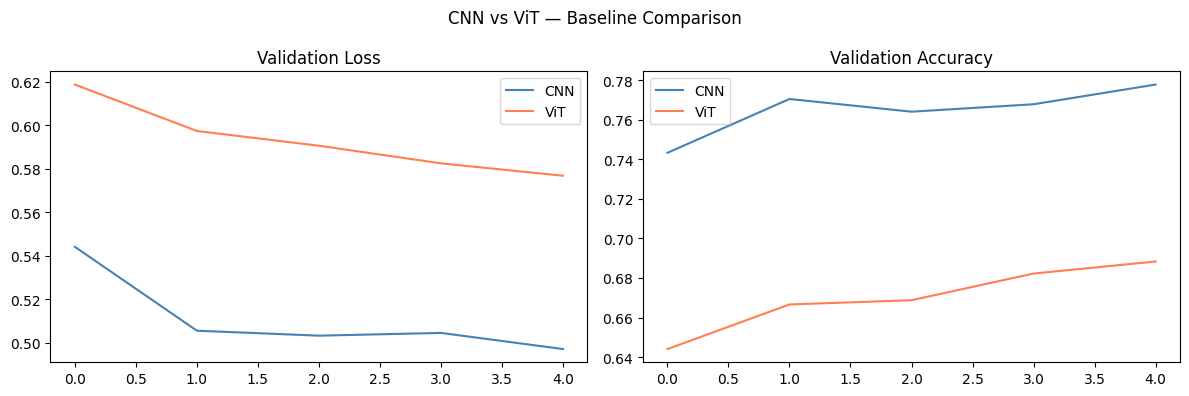

In [16]:
ig, axes = plt.subplots(1, 2, figsize=(12, 4))

for history, label, color in [
    (cnn_history, 'CNN', 'steelblue'),
    (vit_history, 'ViT', 'coral')
]:
    axes[0].plot(history['val_loss'], label=label, color=color)
    axes[1].plot(history['val_acc'],  label=label, color=color)

axes[0].set_title("Validation Loss");     axes[0].legend()
axes[1].set_title("Validation Accuracy"); axes[1].legend()
plt.suptitle("CNN vs ViT — Baseline Comparison")
plt.tight_layout()
plt.show()